In [1]:
%matplotlib inline
import json, os, re, collections, statistics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
THOUSANDS = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")

def add_value_labels_h(ax, values, fmt="{:,}", pad_frac=0.01, fontsize=10):
    """Annotate horizontal bars to the right of each bar."""
    xmax = max(values) if values else 1
    pad  = xmax * pad_frac
    for i, v in enumerate(values):
        ax.text(v + pad, i, fmt.format(int(v)),
                va="center", ha="left", fontsize=fontsize)

def add_value_labels_v(ax, values, fmt="{:,}", pad_frac=0.02, fontsize=10):
    """Annotate vertical bars above each bar."""
    ymax = max(values) if values else 1
    pad  = ymax * pad_frac
    for i, v in enumerate(values):
        ax.text(i, v + pad, fmt.format(int(v)),
                ha="center", va="bottom", fontsize=fontsize)

SPLIT_DIR = os.path.expanduser("~/osint-project/data/03_splits_v3.4")
OUT_DIR   = os.path.expanduser("~/osint-project/reports/eda")
os.makedirs(OUT_DIR, exist_ok=True)

records = []
for split in ("train", "valid", "test"):
    with open(os.path.join(SPLIT_DIR, f"{split}.jsonl")) as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except Exception:
                pass

total = len(records)
print(f"Total records loaded: {total:,}")


Total records loaded: 16,399


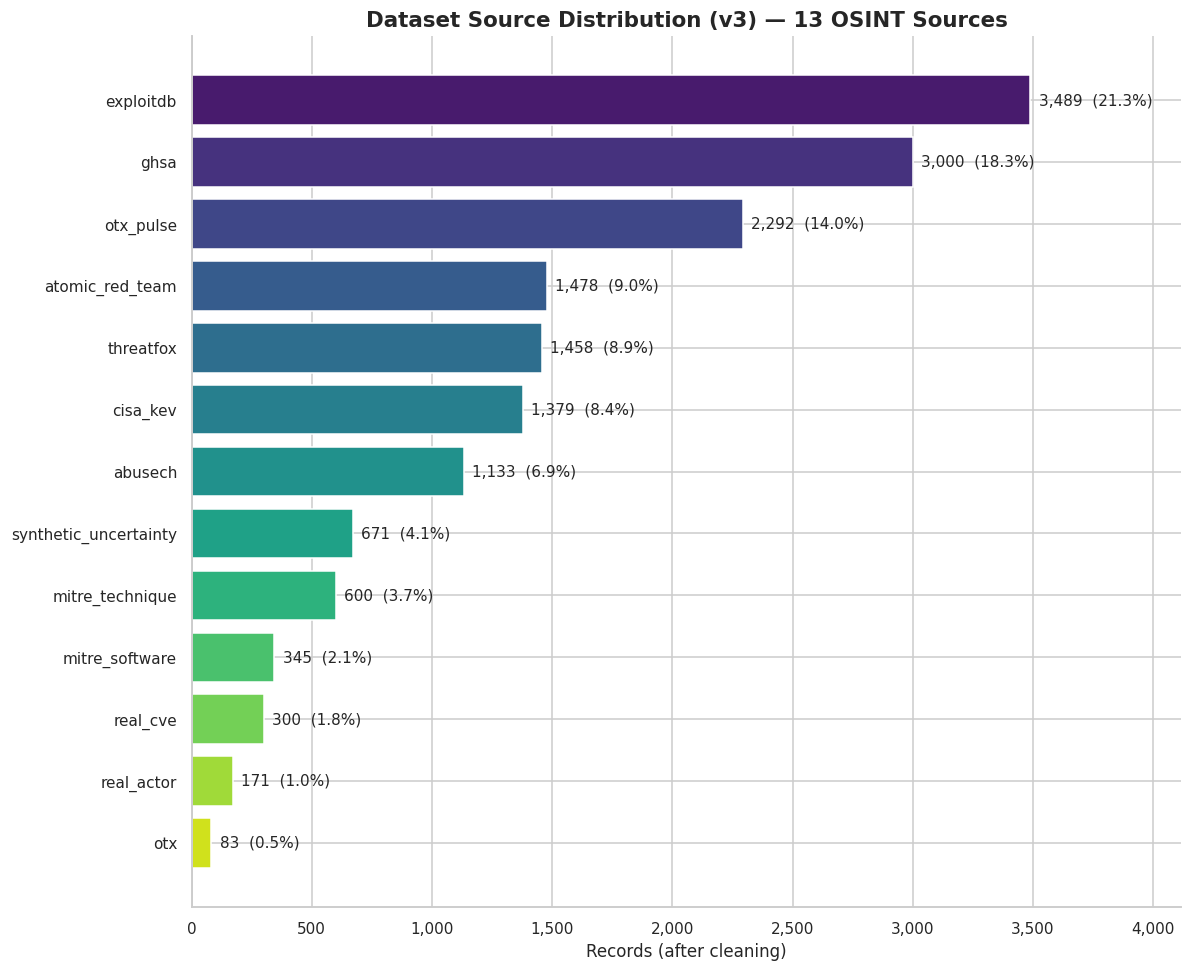


Total sources: 13
Top 3 share:   53.5% of dataset
Smallest:      otx (83 records)


In [2]:
source_counts = collections.Counter(r.get("source", "unknown") for r in records)
items   = source_counts.most_common()
labels  = [s for s, _ in items]
counts  = [c for _, c in items]
pcts    = [c / total * 100 for c in counts]

fig, ax = plt.subplots(figsize=(11, 9))
palette = sns.color_palette("viridis", n_colors=len(labels))
y_pos   = list(range(len(labels)))[::-1]  # largest at top
ax.barh(y_pos, counts, color=palette, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Records (after cleaning)")
ax.set_title(f"Dataset Source Distribution (v3) — {len(labels)} OSINT Sources")
ax.xaxis.set_major_formatter(THOUSANDS)
xmax = max(counts)
for y, v, p in zip(y_pos, counts, pcts):
    ax.text(v + xmax * 0.01, y, f"{v:,}  ({p:.1f}%)",
            va="center", ha="left", fontsize=10)
ax.set_xlim(0, xmax * 1.18)
sns.despine(ax=ax, left=False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/source_distribution.png")
plt.show()

print(f"\nTotal sources: {len(labels)}")
print(f"Top 3 share:   {sum(counts[:3]) / total * 100:.1f}% of dataset")
print(f"Smallest:      {labels[-1]} ({counts[-1]} records)")


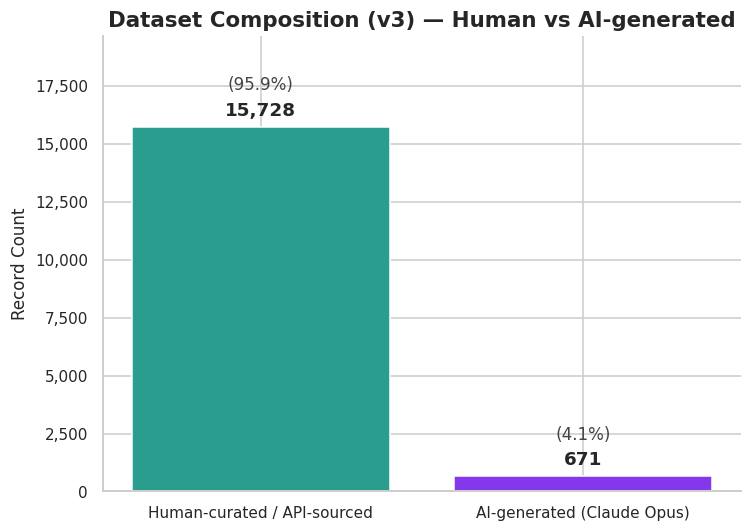

In [3]:
SYNTHETIC = {"synthetic_uncertainty"}

human_count = sum(1 for r in records if r.get("source") not in SYNTHETIC)
ai_count    = sum(1 for r in records if r.get("source") in SYNTHETIC)

labels = ["Human-curated / API-sourced", "AI-generated (Claude Opus)"]
values = [human_count, ai_count]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values,
              color=["#2a9d8f", "#8338ec"], edgecolor="white", linewidth=1)
ax.set_ylabel("Record Count")
ax.set_title("Dataset Composition (v3) — Human vs AI-generated")
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_ylim(0, max(values) * 1.25)
ymax = max(values)
for i, v in enumerate(values):
    pct = v / total * 100
    ax.text(i, v + ymax * 0.02, f"{v:,}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")
    ax.text(i, v + ymax * 0.09, f"({pct:.1f}%)", ha="center", va="bottom",
            fontsize=11, color="#444444")

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/real_vs_synthetic.png")
plt.show()


  Min    : 2 chars
  Max    : 5,755 chars
  Mean   : 844 chars
  Median : 462 chars
  p95    : 2,330 chars
  p99    : 3,503 chars
  Stdev  : 806 chars

  Length bucket breakdown:
    <100            671 ( 4.1%)
    100-500       7,924 (48.3%)
    500-1000      2,940 (17.9%)
    1000-2000     2,821 (17.2%)
    2000-4096     2,008 (12.2%)
    >4096            35 ( 0.2%)


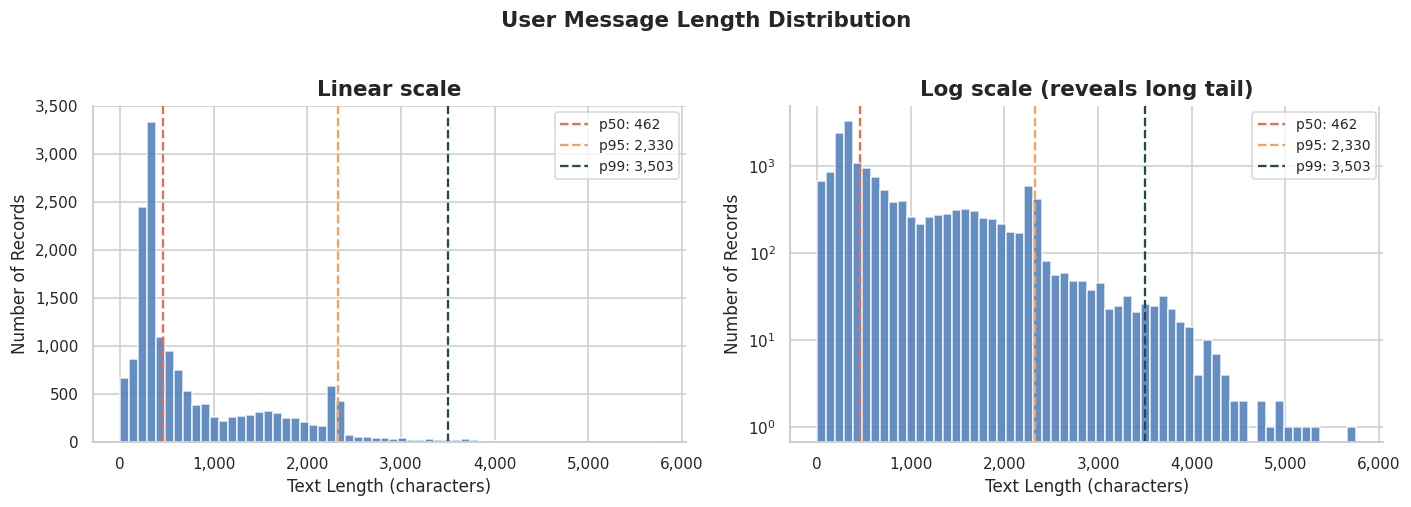

In [4]:
lengths = []
for r in records:
    msgs = r.get("messages", [])
    user_msg = next((m["content"] for m in msgs if m["role"] == "user"), "")
    lengths.append(len(user_msg))

lengths_np = np.array(lengths)
p50 = int(np.percentile(lengths_np, 50))
p95 = int(np.percentile(lengths_np, 95))
p99 = int(np.percentile(lengths_np, 99))

print(f"  Min    : {lengths_np.min():,} chars")
print(f"  Max    : {lengths_np.max():,} chars")
print(f"  Mean   : {lengths_np.mean():,.0f} chars")
print(f"  Median : {p50:,} chars")
print(f"  p95    : {p95:,} chars")
print(f"  p99    : {p99:,} chars")
print(f"  Stdev  : {lengths_np.std():,.0f} chars")

buckets = [("<100", 0, 100), ("100-500", 100, 500), ("500-1000", 500, 1000),
           ("1000-2000", 1000, 2000), ("2000-4096", 2000, 4096), (">4096", 4096, 1e9)]
print("\n  Length bucket breakdown:")
for name, lo, hi in buckets:
    n = int(((lengths_np >= lo) & (lengths_np < hi)).sum())
    print(f"    {name:<12} {n:>6,} ({n / total * 100:4.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, scale, title in [(ax1, "linear", "Linear scale"),
                          (ax2, "log",    "Log scale (reveals long tail)")]:
    ax.hist(lengths_np, bins=60, color="#4a7ab8", edgecolor="white", alpha=0.85)
    for x, label, color in [(p50, f"p50: {p50:,}", "#e76f51"),
                            (p95, f"p95: {p95:,}", "#f4a261"),
                            (p99, f"p99: {p99:,}", "#264653")]:
        ax.axvline(x, color=color, linestyle="--", linewidth=1.5, label=label)
    ax.set_yscale(scale)
    ax.set_xlabel("Text Length (characters)")
    ax.set_ylabel("Number of Records")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(THOUSANDS)
    if scale == "linear":
        ax.yaxis.set_major_formatter(THOUSANDS)
    ax.legend(loc="upper right", fontsize=9, frameon=True)

fig.suptitle("User Message Length Distribution", fontsize=14, fontweight="bold", y=1.02)
sns.despine(fig=fig)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/text_length_distribution.png")
plt.show()


  IOC type coverage:
    CVE       7,280 ( 44.4%)
    domain    2,681 ( 16.3%)
    URL       2,639 ( 16.1%)
    hash      2,468 ( 15.0%)
    IP        1,463 (  8.9%)
    no IOC    4,469 ( 27.3%)


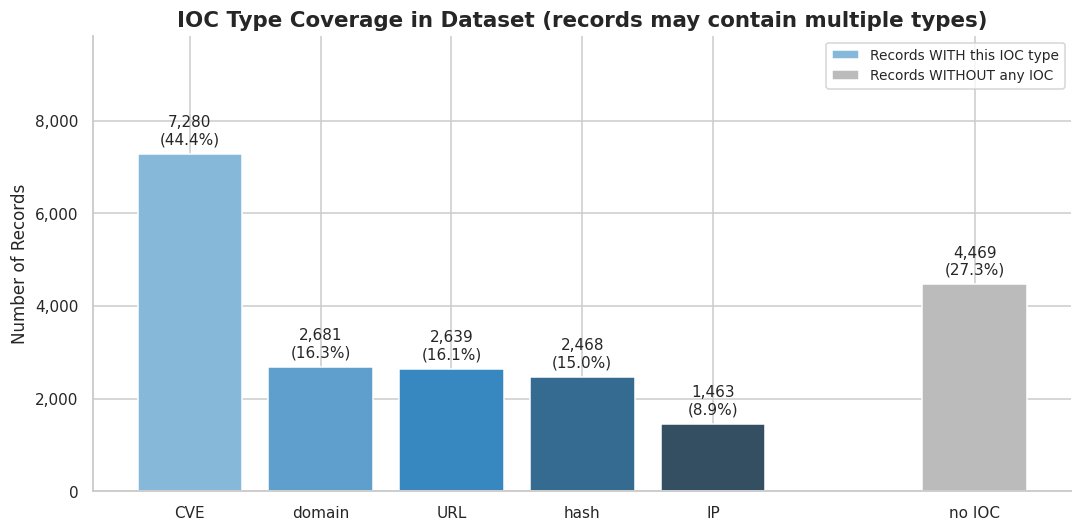

In [5]:
patterns = {
    "CVE":    r"CVE-\d{4}-\d+",
    "IP":     r"\b\d{1,3}\[\.\]\d{1,3}\[\.\]\d{1,3}\[\.\]\d{1,3}\b",
    "domain": r"\b[a-zA-Z0-9\-]+\[\.\][a-zA-Z]{2,10}\b",
    "hash":   r"\b[a-fA-F0-9]{32,64}\b",
    "URL":    r"hxxps?://",
}

ioc_counts = {k: 0 for k in patterns}
no_ioc = 0
for r in records:
    full_text = " ".join(m["content"] for m in r.get("messages", []))
    hit = False
    for kind, pat in patterns.items():
        flags = re.IGNORECASE if kind == "CVE" else 0
        if re.search(pat, full_text, flags):
            ioc_counts[kind] += 1
            hit = True
    if not hit:
        no_ioc += 1
ordered = sorted(ioc_counts.items(), key=lambda x: -x[1])
labels_ioc  = [k for k, _ in ordered]
values_ioc  = [v for _, v in ordered]
pcts_ioc    = [v / total * 100 for v in values_ioc]

print("  IOC type coverage:")
for k, v, p in zip(labels_ioc, values_ioc, pcts_ioc):
    print(f"    {k:<8} {v:>6,} ({p:5.1f}%)")
print(f"    {'no IOC':<8} {no_ioc:>6,} ({no_ioc / total * 100:5.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("Blues_d", n_colors=len(labels_ioc))
x_ioc  = list(range(len(labels_ioc)))
x_none = [len(labels_ioc) + 1]  # gap separator

ax.bar(x_ioc, values_ioc, color=palette, edgecolor="white", label="Records WITH this IOC type")
ax.bar(x_none, [no_ioc], color="#bbbbbb", edgecolor="white", label="Records WITHOUT any IOC")
ax.set_xticks(x_ioc + x_none)
ax.set_xticklabels(labels_ioc + ["no IOC"])
ymax = max(values_ioc + [no_ioc])
ax.set_ylim(0, ymax * 1.35)
for i, v, p in zip(x_ioc, values_ioc, pcts_ioc):
    ax.text(i, v + ymax * 0.02, f"{v:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.text(x_none[0], no_ioc + ymax * 0.02,
        f"{no_ioc:,}\n({no_ioc / total * 100:.1f}%)",
        ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Number of Records")
ax.set_title("IOC Type Coverage in Dataset (records may contain multiple types)")
ax.yaxis.set_major_formatter(THOUSANDS)
ax.legend(loc="upper right", frameon=True, fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ioc_coverage.png")
plt.show()


  Unique techniques referenced : 781
  Total technique mentions     : 60,990
  Mean mentions per technique  : 78.1



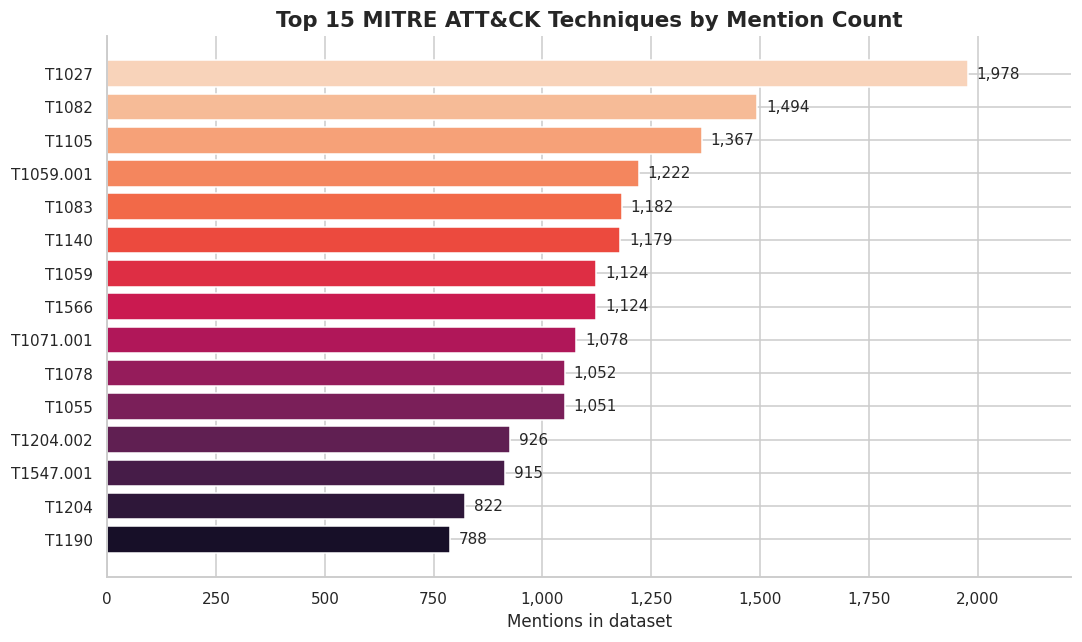

In [6]:
all_techniques = []
for r in records:
    full_text = " ".join(m["content"] for m in r.get("messages", []))
    all_techniques.extend(re.findall(r"T\d{4}(?:\.\d{3})?", full_text))

tech_counter = collections.Counter(all_techniques)
print(f"  Unique techniques referenced : {len(tech_counter):,}")
print(f"  Total technique mentions     : {sum(tech_counter.values()):,}")
print(f"  Mean mentions per technique  : {sum(tech_counter.values()) / max(len(tech_counter),1):.1f}")
print()

top = tech_counter.most_common(15)
labels_t = [t for t, _ in top]
counts_t = [c for _, c in top]

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("rocket_r", n_colors=len(labels_t))
y_pos = list(range(len(labels_t)))[::-1]
ax.barh(y_pos, counts_t, color=palette, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_t)
ax.set_xlabel("Mentions in dataset")
ax.set_title("Top 15 MITRE ATT&CK Techniques by Mention Count")
ax.xaxis.set_major_formatter(THOUSANDS)

xmax = max(counts_t)
ax.set_xlim(0, xmax * 1.12)
for y, v in zip(y_pos, counts_t):
    ax.text(v + xmax * 0.01, y, f"{v:,}", va="center", ha="left", fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/attack_top_techniques.png")
plt.show()


  Records by kill chain phase (records can cover multiple):

    Command & Control         1,782 ( 10.9%)
    Privilege Escalation        628 (  3.8%)
    Execution                   575 (  3.5%)
    Persistence                 406 (  2.5%)
    Impact                      283 (  1.7%)
    Credential Access           256 (  1.6%)
    Initial Access              254 (  1.5%)
    Exfiltration                102 (  0.6%)
    Reconnaissance               98 (  0.6%)
    Lateral Movement             63 (  0.4%)


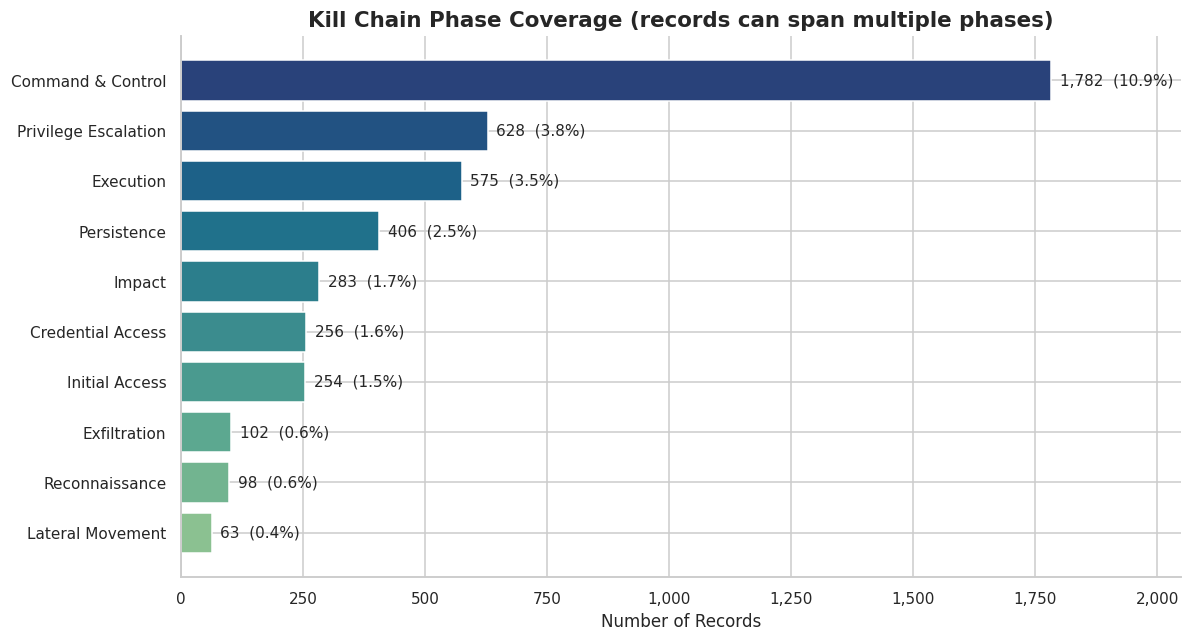

In [7]:
kill_chain_keywords = {
    "Reconnaissance":       ['reconnaissance', 'recon', 'scanning', 'enumeration', 'osint'],
    "Initial Access":       ['initial access', 'phishing', 'spear phishing', 'watering hole'],
    "Execution":            ['code execution', 'shellcode', 'macro', 'script execution'],
    "Persistence":          ['persistence', 'backdoor', 'rootkit', 'scheduled task'],
    "Privilege Escalation": ['privilege escalation', 'privesc', 'elevation of privilege'],
    "Credential Access":    ['credential', 'mimikatz', 'lsass', 'kerberoasting'],
    "Lateral Movement":     ['lateral movement', 'pass the hash', 'psexec', 'rdp'],
    "Command & Control":    ['command and control', 'c2', 'cobalt strike', 'beacon'],
    "Exfiltration":         ['exfiltration', 'data theft', 'exfiltrate'],
    "Impact":               ['ransomware', 'wiper', 'encrypt files', 'destruction'],
}

phase_counts = collections.defaultdict(int)
for r in records:
    asst_text = next((m["content"].lower() for m in r.get("messages", [])
                      if m["role"] == "assistant"), "")
    for phase, kws in kill_chain_keywords.items():
        if any(kw in asst_text for kw in kws):
            phase_counts[phase] += 1

print("  Records by kill chain phase (records can cover multiple):\n")
for phase, count in sorted(phase_counts.items(), key=lambda x: -x[1]):
    print(f"    {phase:<24} {count:>6,} ({count / total * 100:5.1f}%)")

pairs = sorted(phase_counts.items(), key=lambda x: x[1])  # ascending so top of chart = largest
phases = [p for p, _ in pairs]
counts = [c for _, c in pairs]
pcts   = [c / total * 100 for c in counts]

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("crest", n_colors=len(phases))
y_pos   = list(range(len(phases)))
ax.barh(y_pos, counts, color=palette, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(phases)
ax.set_xlabel("Number of Records")
ax.set_title("Kill Chain Phase Coverage (records can span multiple phases)")
ax.xaxis.set_major_formatter(THOUSANDS)

xmax = max(counts)
ax.set_xlim(0, xmax * 1.15)
for y, v, p in zip(y_pos, counts, pcts):
    ax.text(v + xmax * 0.01, y, f"{v:,}  ({p:.1f}%)",
            va="center", ha="left", fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kill_chain_coverage.png")
plt.show()


In [8]:
print(f"  Total training records        : {total:,}")
print(f"  Unique data sources           : {len(source_counts)}")
print(f"  Human vs AI ratio             : {human_count/total*100:.1f}% human / {ai_count/total*100:.1f}% AI (Claude Opus)")
print(f"  Avg text length (user msg)    : {lengths_np.mean():.0f} chars (median {p50:,}, p99 {p99:,})")
print(f"  Records with at least 1 IOC   : {total - no_ioc:,} ({(total - no_ioc)/total*100:.1f}%)")
print(f"  Unique ATT&CK techniques      : {len(tech_counter):,}")
print(f"  Kill chain phases covered     : {len([p for p,c in phase_counts.items() if c > 0])}/10")
print()
print(f"  All charts saved to: {OUT_DIR}/")


  Total training records        : 16,399
  Unique data sources           : 13
  Human vs AI ratio             : 95.9% human / 4.1% AI (Claude Opus)
  Avg text length (user msg)    : 844 chars (median 462, p99 3,503)
  Records with at least 1 IOC   : 11,930 (72.7%)
  Unique ATT&CK techniques      : 781
  Kill chain phases covered     : 10/10

  All charts saved to: /home/maximuz/osint-project/reports/eda/


  Eval: 700 test reports + 80-item fake-real probe
  Metric                              BASE      FT    delta
  Honesty F1 (refuse)                0.621   0.987   +0.367
  Honesty accuracy                   0.725   0.988   +0.263
  NER F1 (extraction)                0.604   0.880   +0.277
  BERTScore                          0.819   0.979   +0.160
  ROUGE-L                            0.137   0.887   +0.750
  Hallucination (lower=better)       0.240   0.088   -0.153


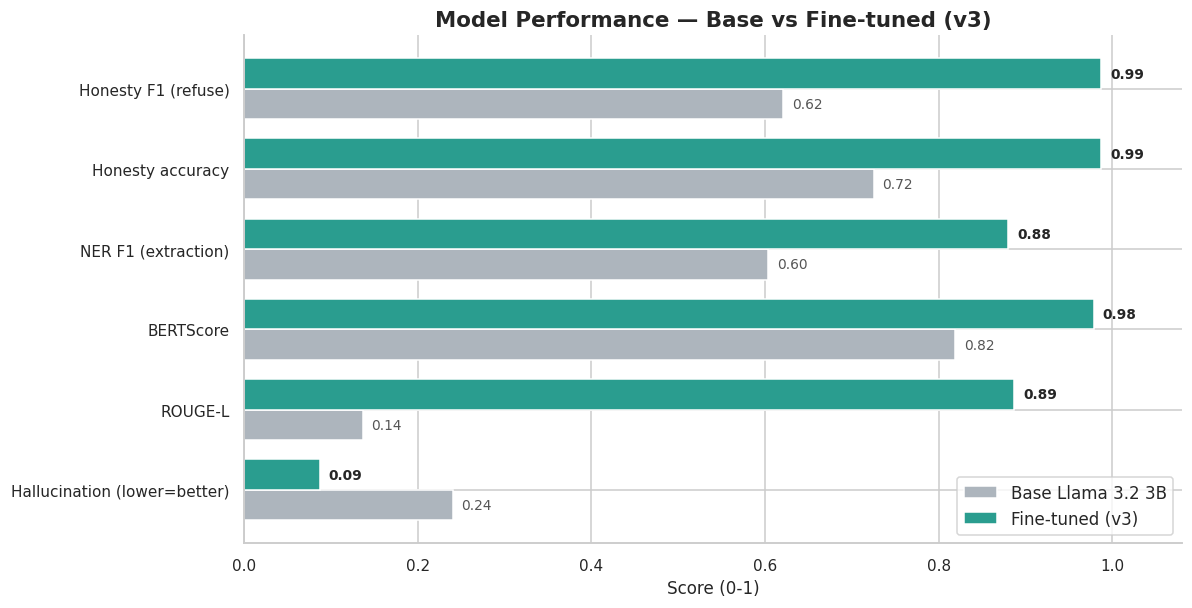

In [9]:
# ===== Model performance: base vs fine-tuned (v3) =====
RESULT = os.path.expanduser("~/osint-project/result.json")
res = json.load(open(RESULT))

metrics = [
    ("Honesty F1 (refuse)",          res["honesty"]["base"]["f1_refuse"], res["honesty"]["ft"]["f1_refuse"]),
    ("Honesty accuracy",             res["honesty"]["base"]["accuracy"],  res["honesty"]["ft"]["accuracy"]),
    ("NER F1 (extraction)",          res["ner"]["base"]["f1"],            res["ner"]["ft"]["f1"]),
    ("BERTScore",                    res["bertscore"]["base"],            res["bertscore"]["ft"]),
    ("ROUGE-L",                      res["rouge_l"]["base"],              res["rouge_l"]["ft"]),
    ("Hallucination (lower=better)", res["hallucination_rate"]["base"],   res["hallucination_rate"]["ft"]),
]

print(f"  Eval: {res['test_sample_size']} test reports + 80-item fake-real probe")
print(f"  {'Metric':32}{'BASE':>8}{'FT':>8}{'delta':>9}")
for name, b, f in metrics:
    print(f"  {name:32}{b:>8.3f}{f:>8.3f}{f - b:>+9.3f}")

names  = [m[0] for m in metrics]
base_v = [m[1] for m in metrics]
ft_v   = [m[2] for m in metrics]

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(names))
hbar = 0.38
ax.barh(y + hbar / 2, base_v, height=hbar, label="Base Llama 3.2 3B", color="#adb5bd", edgecolor="white")
ax.barh(y - hbar / 2, ft_v,   height=hbar, label="Fine-tuned (v3)",   color="#2a9d8f", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlim(0, 1.08)
ax.set_xlabel("Score (0-1)")
ax.set_title("Model Performance — Base vs Fine-tuned (v3)")
ax.legend(loc="lower right")
for yi, (b, f) in enumerate(zip(base_v, ft_v)):
    ax.text(b + 0.01, yi + hbar / 2, f"{b:.2f}", va="center", fontsize=9, color="#555")
    ax.text(f + 0.01, yi - hbar / 2, f"{f:.2f}", va="center", fontsize=9, fontweight="bold")
fig.savefig(os.path.join(OUT_DIR, "model_performance.png"))
plt.show()